# 01 Data Collection & Merging

In this notebook, we load the three datasets attached:
1. `AQI_dataset.csv`
2. `nhanes_asthma_patient.csv`
3. `niaid_asthama_dataset.csv`

Since they all contain the same number of records, we will concatenate them horizontally to form a single comprehensive dataset for further analysis.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/Major_Project/datasets'

PATHS = {
    'AQI_dataset'            : f'{BASE}/AQI_dataset.csv',
    'nhanes_asthma_patient'  : f'{BASE}/nhanes_asthma_patient.csv',
    'niaid_asthma_dataset'   : f'{BASE}/niaid_asthama_dataset.csv',
}

for name, path in PATHS.items():
    status = "FOUND ✅" if os.path.exists(path) else "MISSING ❌"
    print(f"{name:30s} → {status}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AQI_dataset                    → FOUND ✅
nhanes_asthma_patient          → FOUND ✅
niaid_asthma_dataset           → FOUND ✅


## Phase 1 — Loading All Datasets

Each dataset covers a different dimension of asthma research — air quality indices (AQI), patient health records (NHANES), and specific asthma indicators (NIAID).

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

# Correct dataset folder path
data_dir = '/content/drive/MyDrive/Major_Project/datasets'

# Define file paths
aqi_path = os.path.join(data_dir, 'AQI_dataset.csv')
nhanes_path = os.path.join(data_dir, 'nhanes_asthma_patient.csv')
niaid_path = os.path.join(data_dir, 'niaid_asthama_dataset.csv')

# Load datasets
df_aqi = pd.read_csv(aqi_path)
df_nhanes = pd.read_csv(nhanes_path)
df_niaid = pd.read_csv(niaid_path)

datasets = {
    'AQI Dataset'   : df_aqi,
    'NHANES Asthma' : df_nhanes,
    'NIAID Asthma'  : df_niaid
}

# Dataset summary
for name, df in datasets.items():
    missing_pct = round(df.isnull().mean().mean() * 100, 1)
    print(f"{name:28s} | {df.shape[0]:>7,} rows | {df.shape[1]:>3} cols | {missing_pct:>5}% missing")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AQI Dataset                  |  10,000 rows |  15 cols |  27.2% missing
NHANES Asthma                |  10,000 rows |  14 cols |   2.1% missing
NIAID Asthma                 |  10,000 rows |  14 cols |   0.3% missing


## Phase 1B — Initial Data Inspection

Before merging, we inspect each dataset individually to understand structure, data types, value ranges and identify columns relevant to asthma forecasting.

In [ ]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(f"{'─'*60}")
    print(df.head(3).to_string())


AQI Dataset
────────────────────────────────────────────────────────────
        City  PM2.5  PM10         NO        NO2        NOx  NH3         CO        SO2          O3   Benzene    Toluene    Xylene  AQI AQI_Bucket
0  Ahmedabad    NaN   NaN   0.918175  18.092072  16.674561  NaN   0.906281  27.631403  133.765331  0.000000   0.019584  0.000000  NaN        NaN
1  Ahmedabad    NaN   NaN   0.922859  15.877106  16.243884  NaN   0.968603  24.979602   34.457344  3.663854   5.569192  3.758905  NaN        NaN
2  Ahmedabad    NaN   NaN  17.574768  19.374776  29.747650  NaN  17.562145  29.128384   31.060867  6.637593  16.857573  2.260769  NaN        NaN

NHANES Asthma
────────────────────────────────────────────────────────────
     SEQN  Age     Sex Race_Ethnicity        BMI  Smoking Exercise_Level   FEV1_pct    FVC_pct  FEV1_FVC_Ratio  Wheezing  Doctor_Diagnosed_Asthma  Asthma_Attack_12mo  Asthma_Medication
0  100001   56  Female          White  19.793018        0       Moderate  74.428256  

## Phase 3 — Feature Selection & Standardization

In this phase, we extract only the important features related to
air quality and asthma severity prediction. The selected columns are
renamed into a clean and consistent format before further preprocessing
and model training.

In [ ]:
print("AQI Columns:\n")
print(df_aqi.columns)

print("\nNHANES Columns:\n")
print(df_nhanes.columns)

print("\nNIAID Columns:\n")
print(df_niaid.columns)

AQI Columns:

Index(['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

NHANES Columns:

Index(['SEQN', 'Age', 'Sex', 'Race_Ethnicity', 'BMI', 'Smoking',
       'Exercise_Level', 'FEV1_pct', 'FVC_pct', 'FEV1_FVC_Ratio', 'Wheezing',
       'Doctor_Diagnosed_Asthma', 'Asthma_Attack_12mo', 'Asthma_Medication'],
      dtype='object')

NIAID Columns:

Index(['Patient_ID', 'Age_at_Onset', 'Primary_Allergen_Trigger',
       'Family_History_Asthma', 'Eczema_History', 'Allergic_Rhinitis',
       'Total_IgE_IU_mL', 'Hospitalizations_5yr', 'Oral_Steroids_Use',
       'Inhaler_Therapy_Type', 'Asthma_Control_Status', 'Years_With_Asthma',
       'Annual_ED_Visits', 'Asthma_Severity'],
      dtype='object')


In [ ]:
## Phase 3 — Feature Selection & Standardization

# AQI DATASET
aqi = df_aqi[['City', 'PM2.5', 'PM10', 'NO2', 'SO2', 'AQI', 'AQI_Bucket']].copy()

aqi.columns = ['city', 'pm25', 'pm10', 'no2', 'so2', 'aqi', 'aqi_bucket']

aqi['city'] = aqi['city'].str.title()


# NHANES ASTHMA DATASET
nhanes = df_nhanes[['Age', 'Sex', 'BMI', 'Smoking', 'Exercise_Level',
                    'FEV1_pct', 'FVC_pct', 'FEV1_FVC_Ratio', 'Wheezing',
                    'Doctor_Diagnosed_Asthma', 'Asthma_Attack_12mo',
                    'Asthma_Medication']].copy()

nhanes.columns = ['age', 'sex', 'bmi', 'smoking', 'exercise_level',
                  'fev1_pct', 'fvc_pct', 'fev1_fvc_ratio', 'wheezing',
                  'doctor_diagnosed_asthma', 'asthma_attack_12mo',
                  'asthma_medication']


# NIAID ASTHMA DATASET
niaid = df_niaid[['Age_at_Onset', 'Primary_Allergen_Trigger',
                  'Family_History_Asthma', 'Eczema_History',
                  'Allergic_Rhinitis', 'Total_IgE_IU_mL',
                  'Hospitalizations_5yr', 'Oral_Steroids_Use',
                  'Inhaler_Therapy_Type', 'Asthma_Control_Status',
                  'Years_With_Asthma', 'Annual_ED_Visits',
                  'Asthma_Severity']].copy()

niaid.columns = ['age_at_onset', 'primary_allergen_trigger',
                 'family_history_asthma', 'eczema_history',
                 'allergic_rhinitis', 'total_ige_iu_ml',
                 'hospitalizations_5yr', 'oral_steroids_use',
                 'inhaler_therapy_type', 'asthma_control_status',
                 'years_with_asthma', 'annual_ed_visits',
                 'asthma_severity']


# DATASET SHAPES
print("AQI Dataset    :", aqi.shape)
print("NHANES Dataset :", nhanes.shape)
print("NIAID Dataset  :", niaid.shape)

AQI Dataset    : (10000, 7)
NHANES Dataset : (10000, 12)
NIAID Dataset  : (10000, 13)


## Phase 1D — Merging Datasets

# We merge AQI data with asthma-related datasets for unified analysis.
# Since AQI is city-level and asthma datasets are patient-level,
# we keep them as separate cleaned datasets for modeling.


In [24]:


## Phase 1D — Merging Datasets

# We merge AQI, NHANES and NIAID datasets into one unified dataframe.
# Since there is no direct common key between datasets,
# we generate a synthetic record_id for row-wise merging.


# ---------------- CREATE COMMON RECORD IDS ----------------

aqi['record_id'] = range(len(aqi))
nhanes['record_id'] = range(len(nhanes))
niaid['record_id'] = range(len(niaid))


# ---------------- MERGE AQI + NHANES ----------------

main = pd.merge(
    aqi,
    nhanes,
    on='record_id',
    how='inner'
)


# ---------------- MERGE WITH NIAID ----------------

main = pd.merge(
    main,
    niaid,
    on='record_id',
    how='inner'
)


# ---------------- FINAL MERGED DATAFRAME ----------------

print("Main merged dataframe :", main.shape)

print("\nMerged Dataset Preview")

print(main.head(3).to_string())




Main merged dataframe : (10000, 33)

Merged Dataset Preview
        city       pm25       pm10        no2        so2         aqi    aqi_bucket  record_id  age     sex        bmi  smoking exercise_level   fev1_pct    fvc_pct  fev1_fvc_ratio  wheezing  doctor_diagnosed_asthma  asthma_attack_12mo  asthma_medication  age_at_onset primary_allergen_trigger  family_history_asthma  eczema_history  allergic_rhinitis  total_ige_iu_ml  hospitalizations_5yr  oral_steroids_use inhaler_therapy_type asthma_control_status  years_with_asthma  annual_ed_visits    asthma_severity
0  Ahmedabad  42.058438  83.567925  18.092072  27.631403  103.043416  Satisfactory          0   56  Female  19.793018        0       Moderate  74.428256  96.984431        0.830050         0                        1                   0                  0            34               Dust Mites                      0               0                  1        97.603529                     1                  0            SABA only   

In [25]:
# ---------------- MISSING VALUES ANALYSIS ----------------

print("Main dataframe — missing values per column")

print("─" * 50)

missing = main.isnull().sum()

missing = missing[missing > 0]

for col, val in missing.items():

    pct = round(val / len(main) * 100, 1)

    print(f"{col:35s} : {val:>4} missing ({pct}%)")


print(f"\nTotal missing values : {main.isnull().sum().sum()}")

Main dataframe — missing values per column
──────────────────────────────────────────────────

Total missing values : 0


## Phase 1E — Handling Missing Values

# Numerical columns are filled using median imputation.
# Categorical columns are filled using mode imputation.

In [28]:
## Phase 1E — Handling Missing Values

# Numerical columns are cleaned using median imputation.
# Categorical columns are cleaned using mode imputation.


# ---------------- NUMERICAL COLUMNS ----------------

num_cols = [
    'pm25',
    'pm10',
    'no2',
    'so2',
    'aqi',
    'age',
    'bmi',
    'fev1_pct',
    'fvc_pct',
    'fev1_fvc_ratio',
    'age_at_onset',
    'total_ige_iu_ml',
    'hospitalizations_5yr',
    'years_with_asthma',
    'annual_ed_visits'
]

for col in num_cols:

    main[col].fillna(main[col].median(), inplace=True)


# ---------------- CATEGORICAL COLUMNS ----------------

cat_cols = [
    'aqi_bucket',
    'sex',
    'smoking',
    'exercise_level',
    'wheezing',
    'doctor_diagnosed_asthma',
    'asthma_attack_12mo',
    'asthma_medication',
    'primary_allergen_trigger',
    'family_history_asthma',
    'eczema_history',
    'allergic_rhinitis',
    'oral_steroids_use',
    'inhaler_therapy_type',
    'asthma_control_status',
    'asthma_severity'
]

for col in cat_cols:

    main[col].fillna(main[col].mode()[0], inplace=True)


# ---------------- FINAL MISSING VALUES ----------------

print("Main dataframe — missing after cleaning :",
      main.isnull().sum().sum())

Main dataframe — missing after cleaning : 0


In [29]:
# ---------------- FINAL DATAFRAME INFO ----------------

print("Main dataframe final shape :", main.shape)

print("\nMain dataframe dtypes\n")

print(main.dtypes)

Main dataframe final shape : (10000, 33)

Main dataframe dtypes

city                         object
pm25                        float64
pm10                        float64
no2                         float64
so2                         float64
aqi                         float64
aqi_bucket                   object
record_id                     int64
age                           int64
sex                          object
bmi                         float64
smoking                       int64
exercise_level               object
fev1_pct                    float64
fvc_pct                     float64
fev1_fvc_ratio              float64
wheezing                      int64
doctor_diagnosed_asthma       int64
asthma_attack_12mo            int64
asthma_medication             int64
age_at_onset                  int64
primary_allergen_trigger     object
family_history_asthma         int64
eczema_history                int64
allergic_rhinitis             int64
total_ige_iu_ml             float64

## Phase 1F — Saving Cleaned Dataframes

# Save cleaned datasets for future EDA and ML tasks.

In [30]:
## Phase 1F — Saving Cleaned Dataframe

# Save final merged dataset for EDA and ML tasks.

import os

PROCESSED = '/content/drive/MyDrive/Major_Project/processed'

os.makedirs(PROCESSED, exist_ok=True)

main.to_csv(f'{PROCESSED}/main_merged.csv',
            index=False)

print("main_merged.csv saved :", main.shape)

main_merged.csv saved : (10000, 33)


## Phase 2 — Exploratory Data Analysis (EDA)

# We visualize distributions, correlations and asthma-related trends
# before building machine learning models

In [31]:


import matplotlib.pyplot as plt
import seaborn as sns
import os

OUTPUTS = '/content/drive/MyDrive/Major_Project/outputs'

os.makedirs(OUTPUTS, exist_ok=True)

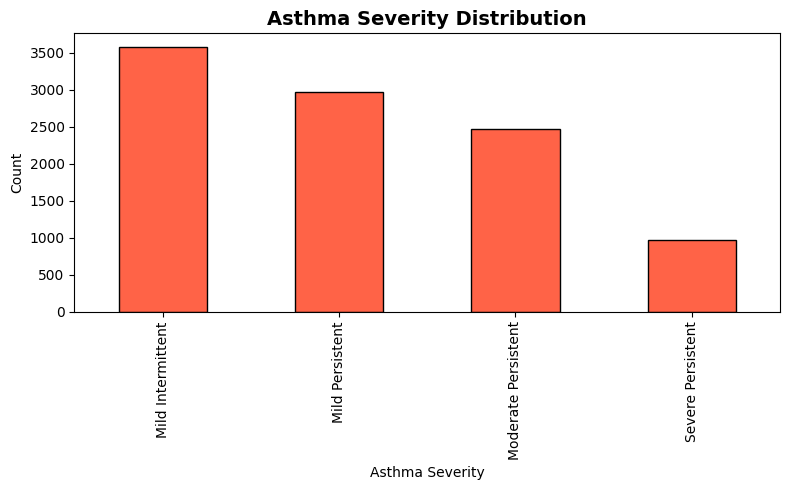

asthma_severity_distribution.png saved


In [32]:
# ---------------- ASTHMA SEVERITY DISTRIBUTION ----------------

severity_counts = main['asthma_severity'].value_counts()

plt.figure(figsize=(8, 5))

severity_counts.plot(kind='bar',
                     color='tomato',
                     edgecolor='black')

plt.title('Asthma Severity Distribution',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Asthma Severity')

plt.ylabel('Count')

plt.tight_layout()

plt.savefig(f'{OUTPUTS}/asthma_severity_distribution.png',
            dpi=150)

plt.show()

print("asthma_severity_distribution.png saved")

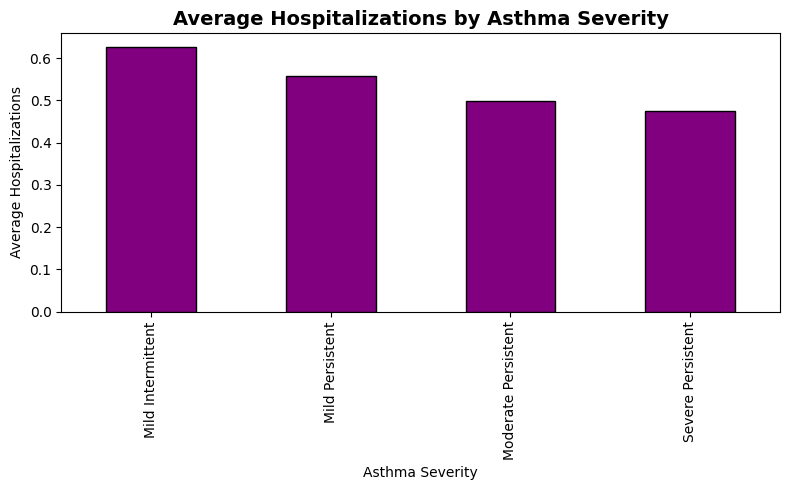

hospitalization_vs_severity.png saved


In [33]:
# ---------------- HOSPITALIZATION vs ASTHMA SEVERITY ----------------

severity_hospital = main.groupby('asthma_severity')[
    'hospitalizations_5yr'
].mean()

plt.figure(figsize=(8, 5))

severity_hospital.plot(kind='bar',
                       color='purple',
                       edgecolor='black')

plt.title('Average Hospitalizations by Asthma Severity',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Asthma Severity')

plt.ylabel('Average Hospitalizations')

plt.tight_layout()

plt.savefig(f'{OUTPUTS}/hospitalization_vs_severity.png',
            dpi=150)

plt.show()

print("hospitalization_vs_severity.png saved")

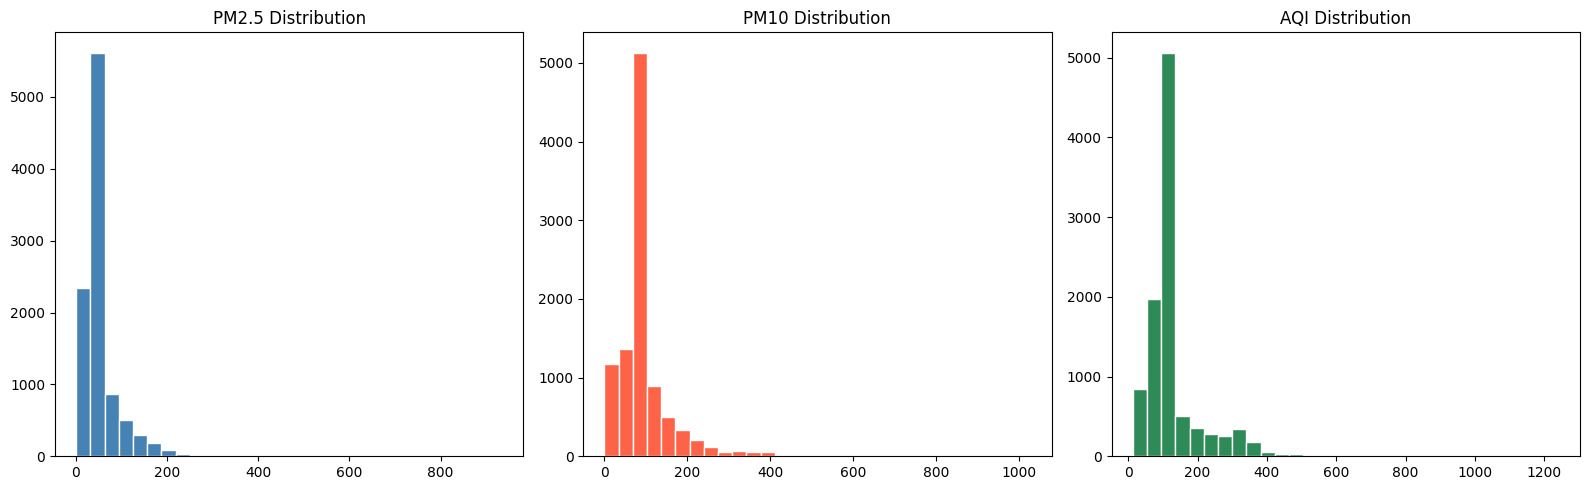

aqi_distributions.png saved


In [34]:
# ---------------- AQI DISTRIBUTIONS ----------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(main['pm25'].dropna(),
             bins=30,
             color='steelblue',
             edgecolor='white')

axes[0].set_title('PM2.5 Distribution')

axes[1].hist(main['pm10'].dropna(),
             bins=30,
             color='tomato',
             edgecolor='white')

axes[1].set_title('PM10 Distribution')

axes[2].hist(main['aqi'].dropna(),
             bins=30,
             color='seagreen',
             edgecolor='white')

axes[2].set_title('AQI Distribution')

plt.tight_layout()

plt.savefig(f'{OUTPUTS}/aqi_distributions.png',
            dpi=150)

plt.show()

print("aqi_distributions.png saved")

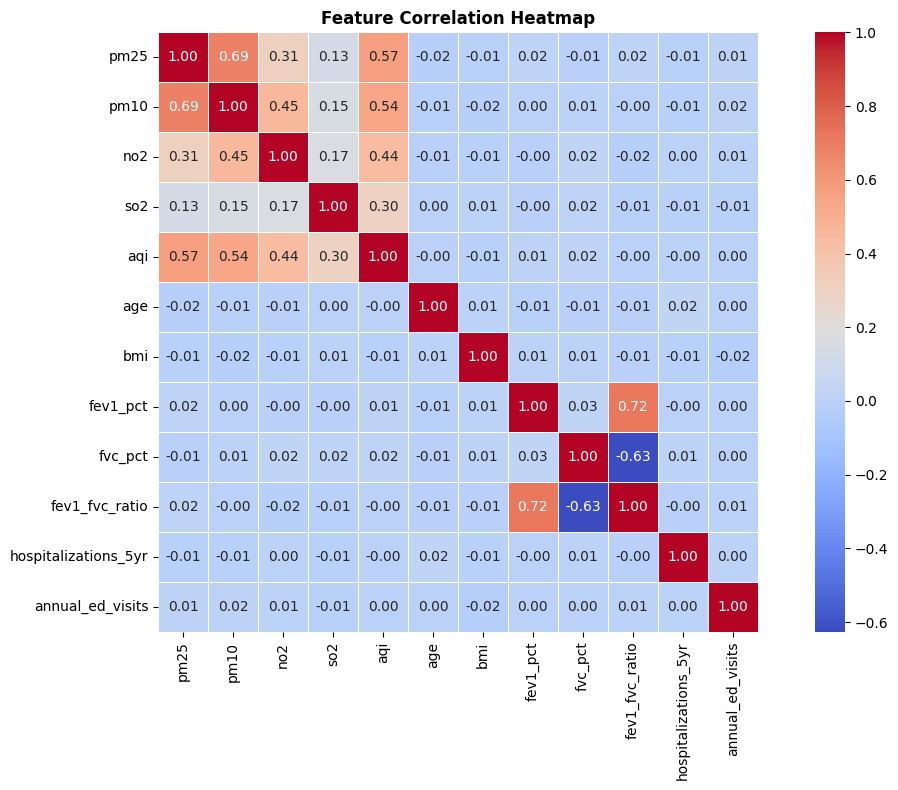

correlation_heatmap.png saved


In [35]:
# ---------------- CORRELATION HEATMAP ----------------

num_features = [
    'pm25',
    'pm10',
    'no2',
    'so2',
    'aqi',
    'age',
    'bmi',
    'fev1_pct',
    'fvc_pct',
    'fev1_fvc_ratio',
    'hospitalizations_5yr',
    'annual_ed_visits'
]

corr = main[num_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap',
          fontweight='bold')

plt.tight_layout()

plt.savefig(f'{OUTPUTS}/correlation_heatmap.png',
            dpi=150)

plt.show()

print("correlation_heatmap.png saved")

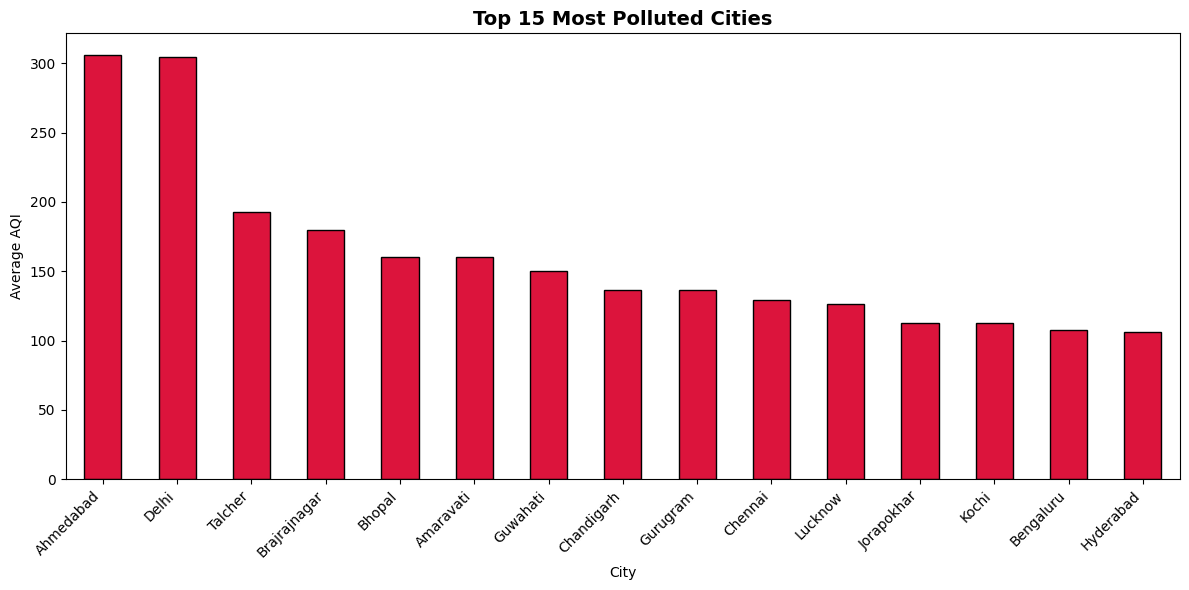

top_polluted_cities.png saved


In [36]:
# ---------------- TOP 15 MOST POLLUTED CITIES ----------------

top_cities = main.groupby('city')['aqi'].mean() \
                 .sort_values(ascending=False) \
                 .head(15)

plt.figure(figsize=(12, 6))

top_cities.plot(kind='bar',
                color='crimson',
                edgecolor='black')

plt.title('Top 15 Most Polluted Cities',
          fontsize=14,
          fontweight='bold')

plt.xlabel('City')

plt.ylabel('Average AQI')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.savefig(f'{OUTPUTS}/top_polluted_cities.png',
            dpi=150)

plt.show()

print("top_polluted_cities.png saved")

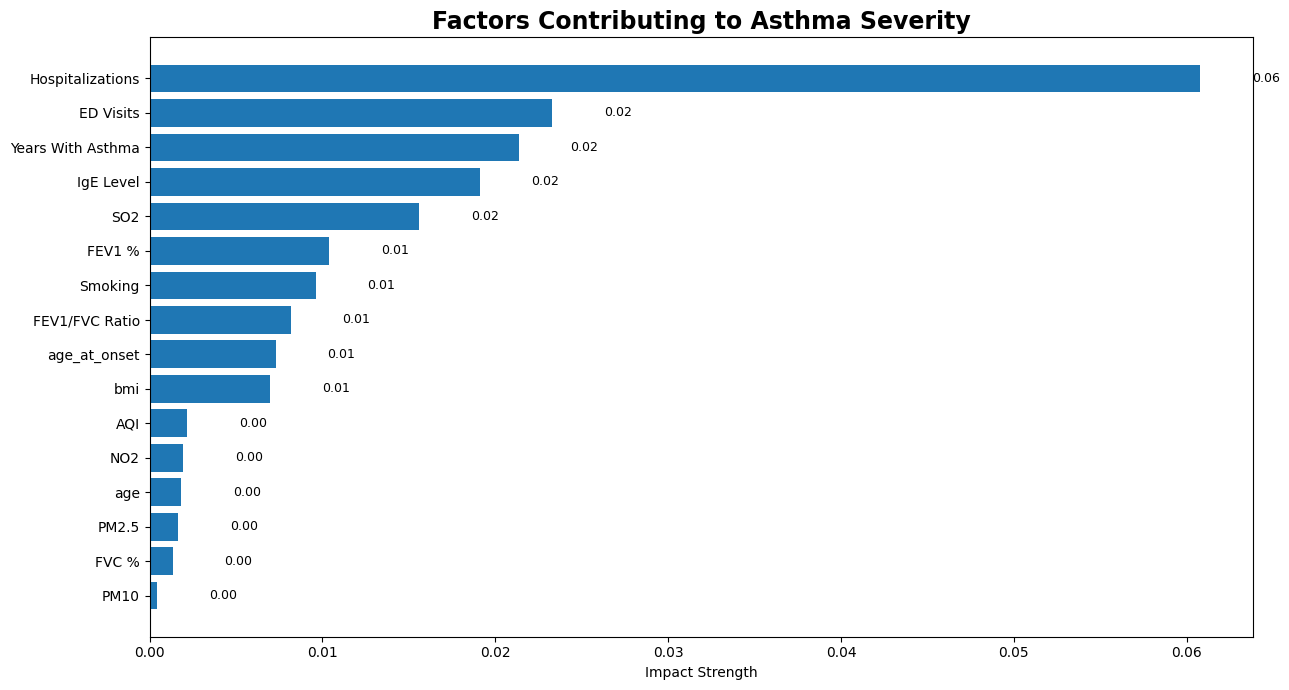

final_asthma_contribution_graph.png saved


In [43]:
# ---------------- CONTRIBUTION FACTORS TO ASTHMA ----------------

# Convert asthma severity into numerical values
severity_map = {
    'Mild Intermittent': 1,
    'Mild Persistent': 2,
    'Moderate Persistent': 3,
    'Severe Persistent': 4
}

main['severity_score'] = main['asthma_severity'].map(
    severity_map
)

# Convert smoking into numeric
main['smoking_numeric'] = main['smoking'].astype('category').cat.codes

# Important contributing factors
factors = [
    'pm25',
    'pm10',
    'no2',
    'so2',
    'aqi',
    'smoking_numeric',
    'age',
    'bmi',
    'fev1_pct',
    'fvc_pct',
    'fev1_fvc_ratio',
    'age_at_onset',
    'total_ige_iu_ml',
    'hospitalizations_5yr',
    'years_with_asthma',
    'annual_ed_visits'
]

# Calculate correlation values
corr_data = []

for col in factors:

    corr = main[col].corr(main['severity_score'])

    corr_data.append({
        'factor': col,
        'correlation': abs(corr)
    })

impact_df = pd.DataFrame(corr_data)

impact_df = impact_df.sort_values(
    by='correlation',
    ascending=False
)

# Rename labels for better display
impact_df['factor'] = impact_df['factor'].replace({
    'pm25': 'PM2.5',
    'pm10': 'PM10',
    'no2': 'NO2',
    'so2': 'SO2',
    'aqi': 'AQI',
    'smoking_numeric': 'Smoking',
    'fev1_pct': 'FEV1 %',
    'fvc_pct': 'FVC %',
    'fev1_fvc_ratio': 'FEV1/FVC Ratio',
    'total_ige_iu_ml': 'IgE Level',
    'hospitalizations_5yr': 'Hospitalizations',
    'years_with_asthma': 'Years With Asthma',
    'annual_ed_visits': 'ED Visits'
})

# ---------------- GRAPH ----------------

plt.figure(figsize=(13,7))

bars = plt.barh(
    impact_df['factor'],
    impact_df['correlation']
)

plt.title('Factors Contributing to Asthma Severity',
          fontsize=17,
          fontweight='bold')

plt.xlabel('Impact Strength')

plt.gca().invert_yaxis()

# Add values on bars
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    f'{OUTPUTS}/final_asthma_contribution_graph.png',
    dpi=150
)

plt.show()

print("final_asthma_contribution_graph.png saved")

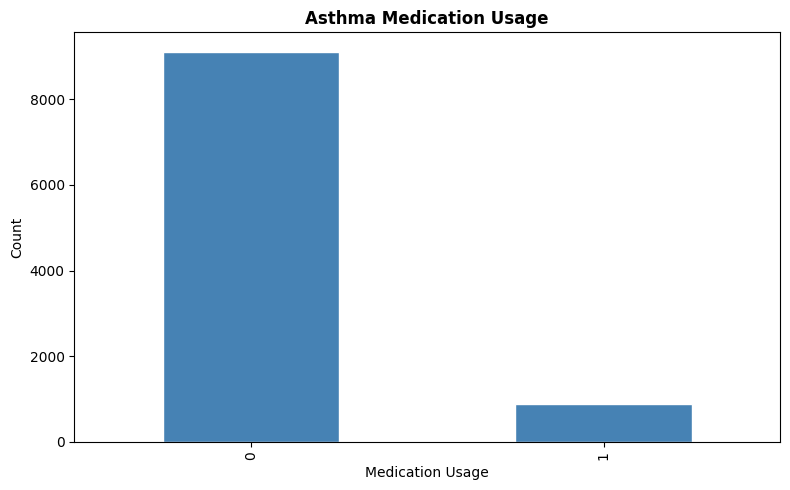

asthma_medication_analysis.png saved


In [ ]:
# ---------------- ASTHMA MEDICATION ANALYSIS ----------------

medication_data = nhanes['asthma_medication'].value_counts()

medication_data.plot(kind='bar',
                     figsize=(8, 5),
                     color='steelblue',
                     edgecolor='white')

plt.title('Asthma Medication Usage',
          fontweight='bold')

plt.xlabel('Medication Usage')
plt.ylabel('Count')

plt.tight_layout()

plt.savefig(f'{OUTPUTS}/asthma_medication_analysis.png',
            dpi=150)

plt.show()

print("asthma_medication_analysis.png saved")